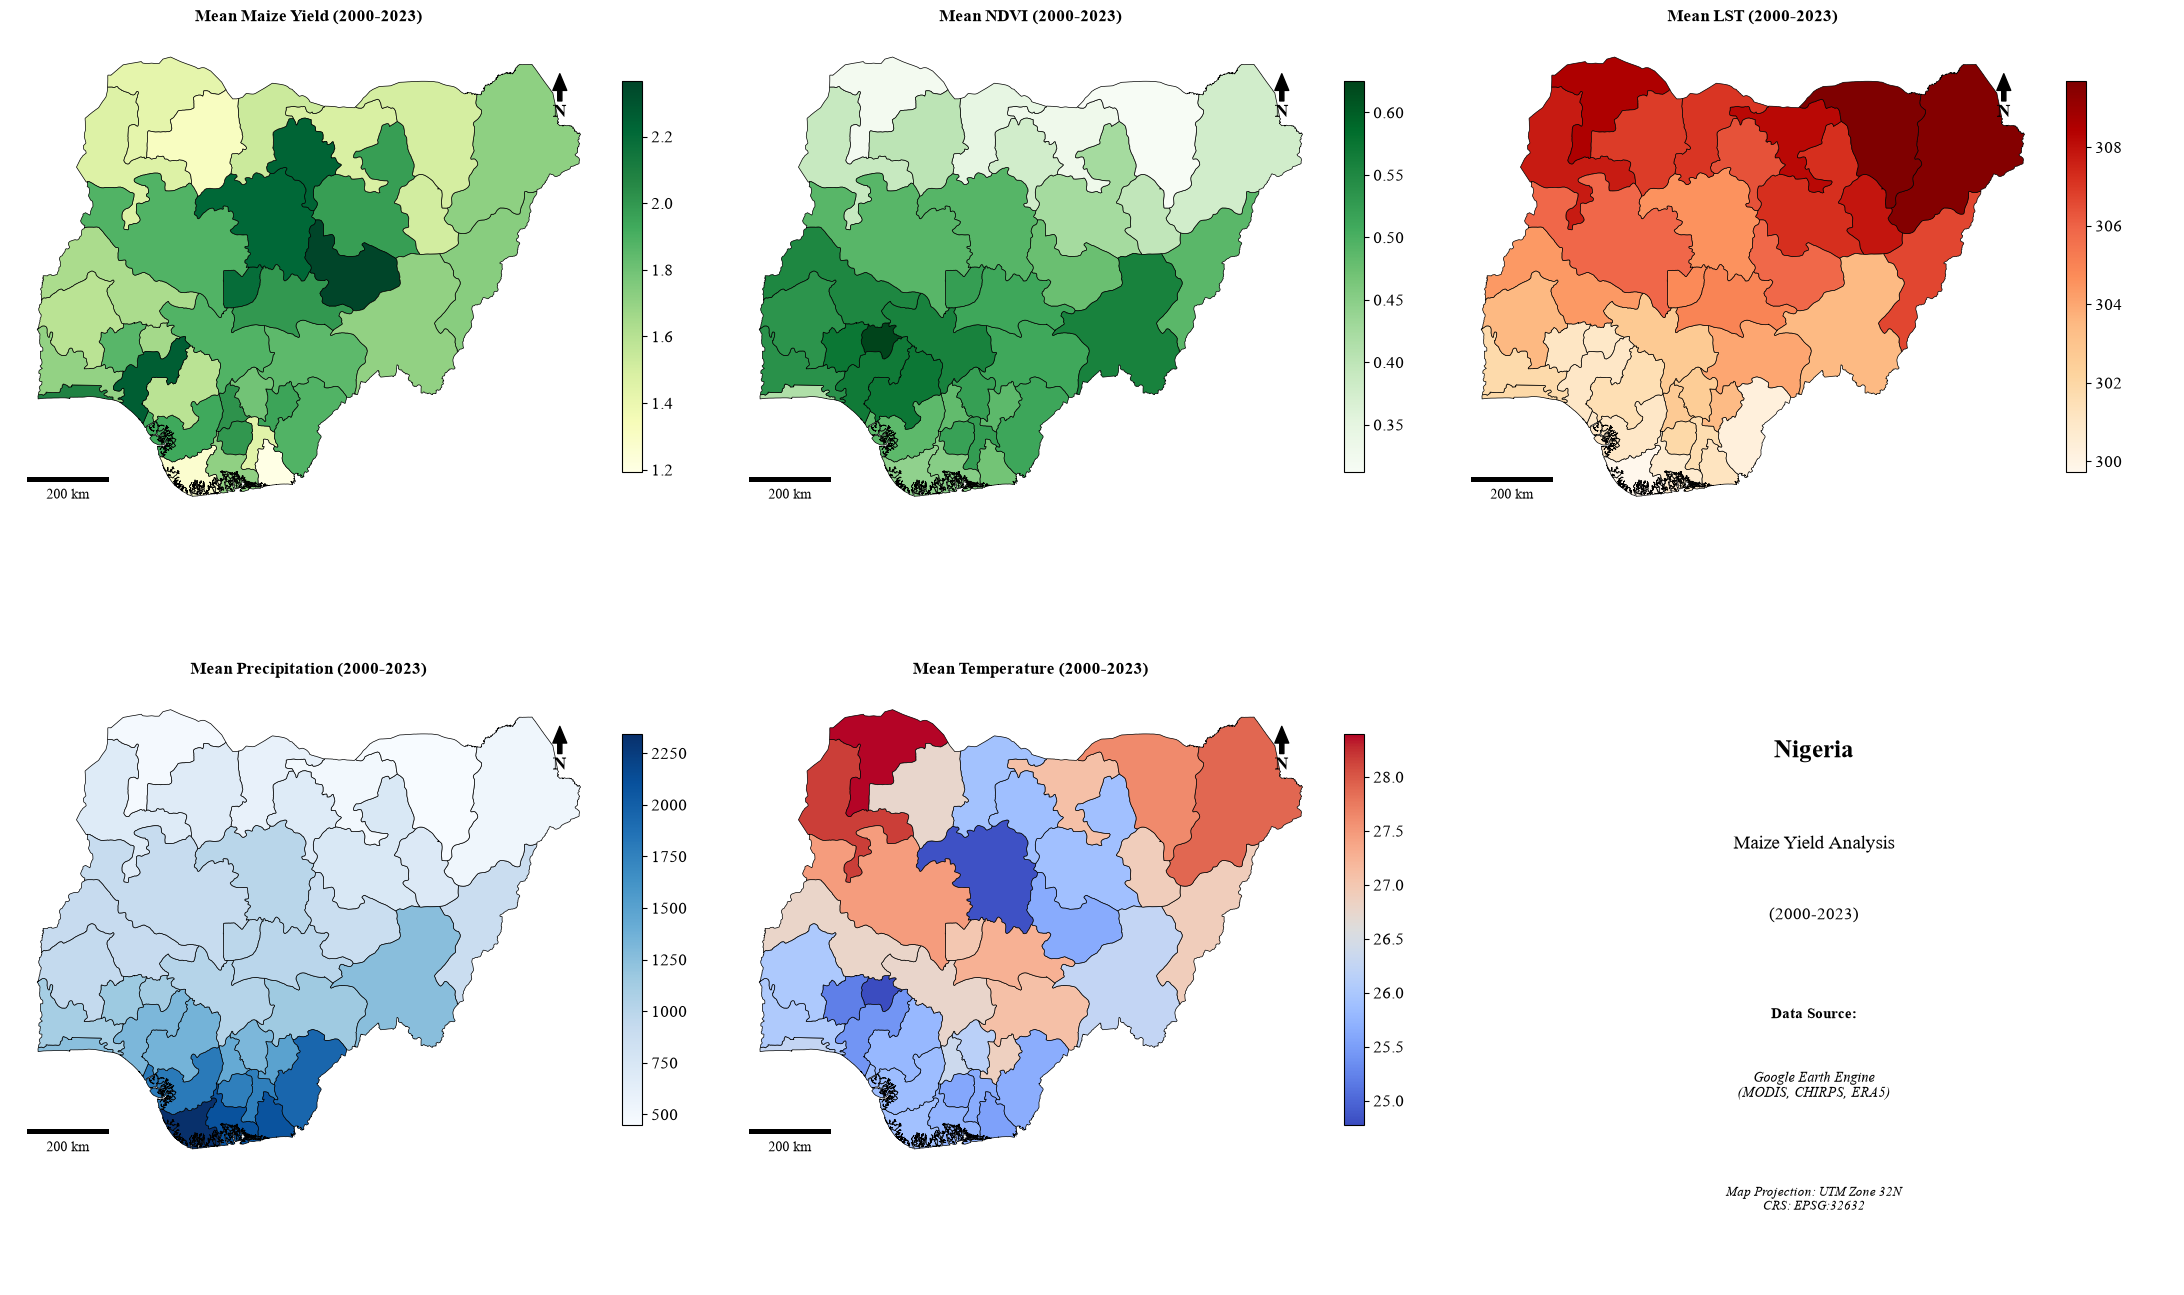

In [2]:
# ============================================================
# Professional Maps with Accurate Scale Bar and Times New Roman Font
# ============================================================

import os
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from matplotlib_scalebar.scalebar import ScaleBar

# ============================================================
# 1. General Settings
# ============================================================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['figure.dpi'] = 100

# ============================================================
# 2. Load Shapefile
# ============================================================
SHAPEFILE_PATH = r"C:\Users\MIG MIG\Desktop\Harvest\HarvestStat-Africa-1.2\public\hvstat_africa_boundary_v1.2.shp"
gdf_africa = gpd.read_file(SHAPEFILE_PATH)

# ============================================================
# 3. Filter Nigeria
# ============================================================
gdf_nigeria = gdf_africa[gdf_africa['country_co'] == 'NG'].copy()
gdf_nigeria = gdf_nigeria[['admin_1', 'geometry']].copy()
gdf_nigeria = gdf_nigeria.rename(columns={'admin_1': 'state'})

# Convert to UTM for accurate Scale Bar
gdf_nigeria_utm = gdf_nigeria.to_crs(epsg=32632)

# ============================================================
# 4. Load Merged Data
# ============================================================
merged_df = pd.read_csv("merged_seasonal_crop_data_v2.csv")

# Filter Maize and yield
maize_df = merged_df[
    (merged_df['product'] == 'Maize') & 
    (merged_df['indicator'] == 'yield')
].copy()

# Compute mean per state
state_avg = maize_df.groupby('admin_1').agg({
    'value': 'mean',
    'NDVI': 'mean',
    'LST': 'mean',
    'Precipitation': 'mean',
    'Temperature': 'mean'
}).reset_index()

state_avg.columns = ['state', 'yield_avg', 'NDVI_avg', 'LST_avg', 'Precipitation_avg', 'Temperature_avg']

# Merge with Shapefile and convert to UTM
gdf_merged = gdf_nigeria.merge(state_avg, on='state', how='left')
gdf_merged_utm = gdf_merged.to_crs(epsg=32632)

# ============================================================
# 5. Professional Map Function
# ============================================================
def plot_map_pro(ax, column, cmap, title, gdf_utm):
    """Plot professional map with Scale Bar and North Arrow"""
    
    gdf_utm.plot(
        column=column,
        cmap=cmap,
        legend=True,
        ax=ax,
        edgecolor='black',
        linewidth=0.5,
        missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
        legend_kwds={'shrink': 0.55, 'pad': 0.02, 'aspect': 20}
    )
    
    ax.set_title(title, fontsize=12, fontweight='bold', 
                 fontfamily='Times New Roman', pad=10)
    
    # Scale Bar
    scalebar = ScaleBar(
        dx=1,
        units='m',
        location='lower left',
        length_fraction=0.25,
        box_alpha=0.7,
        font_properties={'family': 'Times New Roman', 'size': 10},
        color='black',
        scale_loc='bottom',
        border_pad=0.5,
        pad=0.5,
        sep=5
    )
    ax.add_artist(scalebar)
    
    # North Arrow
    x_pos, y_pos = 0.92, 0.92
    arrow_length = 0.08
    ax.annotate('N', 
                xy=(x_pos, y_pos), 
                xytext=(x_pos, y_pos - arrow_length),
                arrowprops=dict(facecolor='black', width=3, headwidth=10),
                ha='center', va='center', 
                fontsize=14, fontweight='bold',
                fontfamily='Times New Roman', 
                xycoords='axes fraction', zorder=10)
    
    ax.axis('off')

# ============================================================
# 6. Plot Maps
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# Map 1: Yield
plot_map_pro(axes[0, 0], 'yield_avg', 'YlGn', 
             'Mean Maize Yield (2000-2023)', gdf_merged_utm)

# Map 2: NDVI
plot_map_pro(axes[0, 1], 'NDVI_avg', 'Greens', 
             'Mean NDVI (2000-2023)', gdf_merged_utm)

# Map 3: LST
plot_map_pro(axes[0, 2], 'LST_avg', 'OrRd', 
             'Mean LST (2000-2023)', gdf_merged_utm)

# Map 4: Precipitation
plot_map_pro(axes[1, 0], 'Precipitation_avg', 'Blues', 
             'Mean Precipitation (2000-2023)', gdf_merged_utm)

# Map 5: Temperature
plot_map_pro(axes[1, 1], 'Temperature_avg', 'coolwarm', 
             'Mean Temperature (2000-2023)', gdf_merged_utm)

# Map 6: Info Panel
axes[1, 2].axis('off')
axes[1, 2].text(0.5, 0.75, 'Nigeria', 
                ha='center', va='center', fontsize=18, fontweight='bold', 
                fontfamily='Times New Roman')
axes[1, 2].text(0.5, 0.62, 'Maize Yield Analysis', 
                ha='center', va='center', fontsize=14, 
                fontfamily='Times New Roman')
axes[1, 2].text(0.5, 0.52, '(2000-2023)', 
                ha='center', va='center', fontsize=12, 
                fontfamily='Times New Roman')
axes[1, 2].text(0.5, 0.38, 'Data Source:', 
                ha='center', va='center', fontsize=11, fontweight='bold',
                fontfamily='Times New Roman')
axes[1, 2].text(0.5, 0.28, 'Google Earth Engine\n(MODIS, CHIRPS, ERA5)', 
                ha='center', va='center', fontsize=10, 
                fontfamily='Times New Roman', style='italic')
axes[1, 2].text(0.5, 0.12, 'Map Projection: UTM Zone 32N\nCRS: EPSG:32632', 
                ha='center', va='center', fontsize=9, 
                fontfamily='Times New Roman', style='italic')

plt.tight_layout()
OUTPUT_DIR = r"C:\Users\MIG MIG\Desktop\Harvest"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "Nigeria_Maps_Professional.png")

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()